# Concept-flipping — results

Faithfulness of LRP relevance over ViT **concept detectors** (attention heads / embedding dims).
Per correctly-classified image and per block we rank detectors by *signed* class-conditional
relevance, then cumulatively perturb them in two orderings and track the target-class
**probability** ratio $\Delta(n)=p'_c(n)/p_c$:

- **most** (MoRF) — most-relevant-first;  **least** (LeRF) — least-relevant-first.

**Metric.** $\mathrm{AOPC}(\text{ordering}) = \mathrm{mean}_n\,(1-\Delta(n))$ over the ablated
fraction $n/N\in[0,1]$ (normalised → head $N{=}6$ and embed-dim $N{=}384$ comparable).
**Concept-flipping score** $= \mathrm{AOPC}_{\text{most}}-\mathrm{AOPC}_{\text{least}}$
$= \int(\Delta_{\text{least}}-\Delta_{\text{most}})\,d(n/N)$ — the paper's area-between-curves.
It is **relative**: comparable across configs/concepts on the same data+model, not an absolute.

All analysis is in probability space (logit ratio dropped — ill-defined when $y_c\le 0$).
Ranking is *signed*: negative-relevance detectors are removed *last* under MoRF and **raise**
$p_c$, so the most-curve can dip then recover; the sign-crossing $n^\star$ (peak cumulative
relevance) is marked. Data come from `lrp_configs`-named recipes — filter by `config`/`concept`.

In [1]:
import glob, numpy as np, polars as pl, matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wilcoxon

RES = Path('../data/results/concept_flipping')
# non-recursive glob skips the _legacy_pre_variants/ archive (old schema)
files = sorted(glob.glob(str(RES / 'flipping_*.parquet')))
df = pl.concat([pl.read_parquet(f) for f in files], how='diagonal')
print('rows:', len(df), '| cols:', df.columns)
df.group_by('config','concept','dataset').agg(
    pl.col('image_idx').n_unique().alias('imgs'),
    pl.col('ordering').unique().alias('orderings'),
    pl.col('block').max().alias('maxblk')).sort('config','concept','dataset')

rows: 10626000 | cols: ['perturbation', 'ordering', 'block', 'layer', 'n', 'prob_target', 'cum_relevance', 'rel_total', 'image_idx', 'class', 'dataset', 'concept', 'config', 'n_detectors', 'prob_baseline', 'delta_prob']


config,concept,dataset,imgs,orderings,maxblk
str,str,str,u32,list[str],i16
"""cp_lrp_baseline""","""embed_dim""","""colored_mnist""",500,"[""most"", ""least""]",11
"""cp_lrp_baseline""","""embed_dim""","""dsprites""",150,"[""most"", ""least""]",11
"""cp_lrp_baseline""","""embed_dim""","""funny_birds""",500,"[""most"", ""least""]",11


## Helpers — per-image curve matrix, bootstrap CI, AOPC, sign-crossing

In [2]:
RNG = np.random.default_rng(0)

def sel(config, concept, dataset):
    """Slice the long frame to one (config, concept, dataset)."""
    return df.filter((pl.col('config')==config) & (pl.col('concept')==concept) &
                     (pl.col('dataset')==dataset))

def curve_matrix(d, block, ordering):
    """(ns, M) — M is images x len(ns) of delta_prob for one block+ordering (n>0)."""
    sub = d.filter((pl.col('block')==block) & (pl.col('ordering')==ordering) & (pl.col('n')>0))
    if sub.is_empty():
        return np.array([]), np.empty((0,0))
    ns = sorted(sub['n'].unique().to_list())
    piv = (sub.pivot(values='delta_prob', index='image_idx', on='n', aggregate_function='mean')
              .sort('image_idx'))
    M = piv.select([pl.col(str(n)) for n in ns]).to_numpy()
    return np.array(ns), M

def boot_ci(M, B=2000, q=(2.5, 97.5)):
    """Mean curve + bootstrap CI band over the image axis (rows of M)."""
    n = M.shape[0]
    idx = RNG.integers(0, n, size=(B, n))
    means = M[idx].mean(axis=1)
    lo, hi = np.percentile(means, q, axis=0)
    return M.mean(0), lo, hi, M.std(0)

def per_image_aopc(d, block, ordering):
    """Normalised AOPC per image = mean_n (1 - delta_prob) over the ablated fraction."""
    sub = d.filter((pl.col('block')==block) & (pl.col('ordering')==ordering) & (pl.col('n')>0))
    return (sub.group_by('image_idx').agg((1 - pl.col('delta_prob')).mean().alias('aopc'))
               .sort('image_idx'))

def crossing(d, block):
    """n* where mean cumulative relevance peaks (net-positive -> net-negative detectors)."""
    cr = (d.filter((pl.col('block')==block) & (pl.col('ordering')=='most') & (pl.col('n')>0))
            .group_by('n').agg(pl.col('cum_relevance').mean().alias('cr')).sort('n'))
    if cr.is_empty():
        return None
    return cr.sort('cr', descending=True)['n'][0]

COLORS = {'most':'tab:red', 'least':'tab:green'}

## 1. Flipping curves per block — Δ(n) with bootstrap CI
Mean curve (solid) + bootstrap-95% CI band (dark, **primary**) + faint ±1 std band (population
spread). Dashed vertical = sign-crossing $n^\star$. x-axis is the ablated fraction $n/N$ so heads
and embedding-dims share a comparable axis.

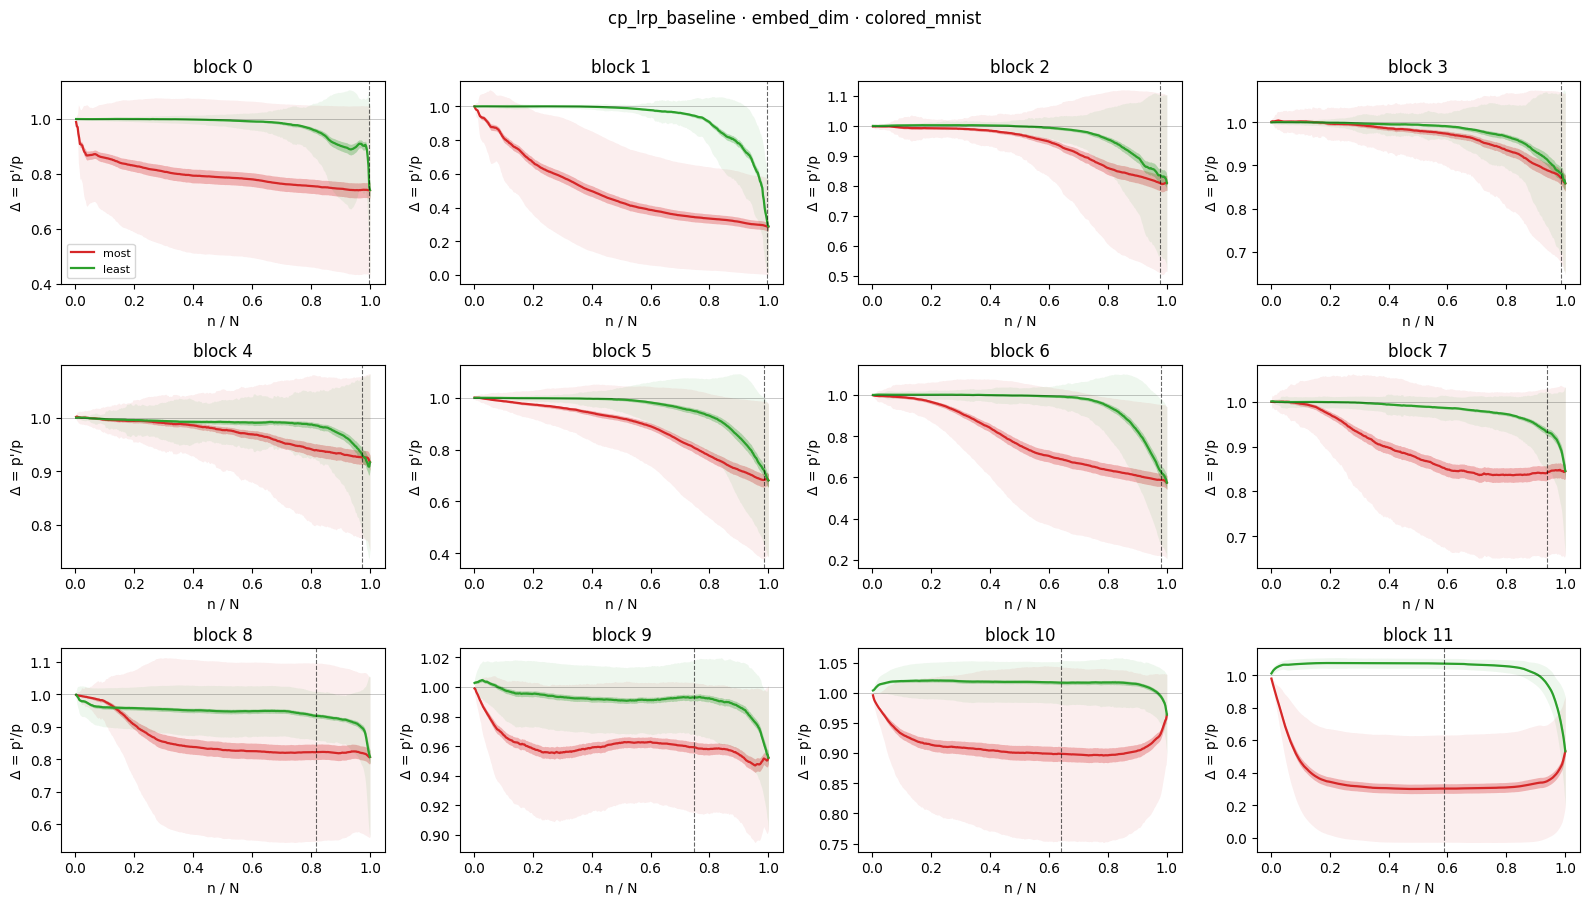

In [3]:
def curve_grid(config, concept, dataset, cols=4):
    d = sel(config, concept, dataset)
    blocks = sorted(d['block'].unique().to_list())
    N = int(d['n_detectors'][0])
    rows = -(-len(blocks)//cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), squeeze=False)
    for ax in axes.flat: ax.axis('off')
    for i, b in enumerate(blocks):
        ax = axes.flat[i]; ax.axis('on')
        for ordering in ('most','least'):
            ns, M = curve_matrix(d, b, ordering)
            if M.size == 0: continue
            mean, lo, hi, sd = boot_ci(M)
            x = ns / N
            ax.plot(x, mean, color=COLORS[ordering], lw=1.6, label=ordering)
            ax.fill_between(x, lo, hi, color=COLORS[ordering], alpha=0.30, lw=0)
            ax.fill_between(x, mean-sd, mean+sd, color=COLORS[ordering], alpha=0.08, lw=0)
        ns_star = crossing(d, b)
        if ns_star: ax.axvline(ns_star/N, color='k', ls='--', lw=0.8, alpha=0.6)
        ax.axhline(1.0, color='k', lw=0.5, alpha=0.3)
        ax.set_title(f'block {b}'); ax.set_xlabel('n / N'); ax.set_ylabel('Δ = p\'/p')
        if i == 0: ax.legend(fontsize=8)
    fig.suptitle(f'{config} · {concept} · {dataset}', y=1.001); fig.tight_layout(); return fig

ex = df.row(0, named=True)
curve_grid(ex['config'], ex['concept'], ex['dataset']); plt.show()

## 2. Normalised AOPC + concept-flipping score per block
AOPC = mean probability drop over $n/N\in[0,1]$ (higher ⇒ steeper flip). A faithful ranking gives
AOPC(most) > AOPC(least). **Score** = AOPC(most) − AOPC(least) (the area-between-curves), per block.

block,most,least,score(most-least)
i64,f64,f64,f64
0,0.205244,0.022394,0.18285
1,0.498953,0.066345,0.432608
2,0.062006,0.025484,0.036522
3,0.032954,0.01989,0.013064
4,0.02997,0.013262,0.016708
…,…,…,…
7,0.103693,0.017763,0.08593
8,0.139941,0.054224,0.085717
9,0.039224,0.00842,0.030804


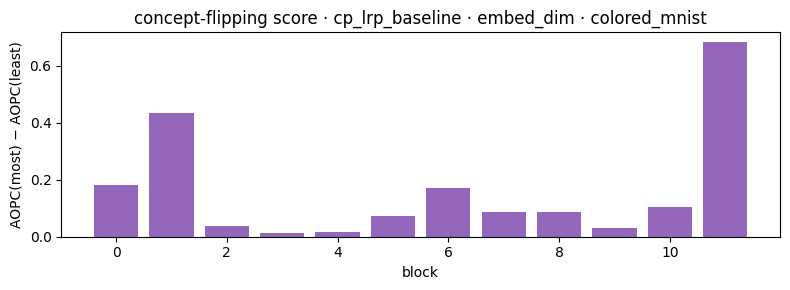

In [4]:
def aopc_table(config, concept, dataset):
    d = sel(config, concept, dataset)
    rows = []
    for b in sorted(d['block'].unique().to_list()):
        rec = {'block': b}
        for o in ('most','least'):
            a = per_image_aopc(d, b, o)
            rec[o] = float(a['aopc'].mean()) if not a.is_empty() else np.nan
        rec['score(most-least)'] = rec['most'] - rec['least']
        rows.append(rec)
    return pl.DataFrame(rows)

def plot_score(config, concept, dataset):
    t = aopc_table(config, concept, dataset)
    fig, ax = plt.subplots(figsize=(8,3))
    ax.bar(t['block'], t['score(most-least)'], color='tab:purple')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('block'); ax.set_ylabel('AOPC(most) − AOPC(least)')
    ax.set_title(f'concept-flipping score · {config} · {concept} · {dataset}')
    fig.tight_layout(); return t

plot_score(ex['config'], ex['concept'], ex['dataset'])

## 3. Significance — does the ordering carry a faithfulness signal? (single cell)
Post-hoc from the gathered parquet. Per-image AOPC, **paired most-vs-least** across images.
Two-sided **Wilcoxon signed-rank** per block — H0: median of $d_i=\mathrm{AOPC}_{most,i}-\mathrm{AOPC}_{least,i}$
is 0 (ordering carries no signal); assumes paired, iid, symmetric differences (no normality).
Report median $d$ + bootstrap-95% CI + p. Holm-correct across blocks when reporting.

In [5]:
def significance(config, concept, dataset):
    d = sel(config, concept, dataset)
    out = []
    for b in sorted(d['block'].unique().to_list()):
        am = per_image_aopc(d, b, 'most'); al = per_image_aopc(d, b, 'least')
        if am.is_empty() or al.is_empty(): continue
        j = am.join(al, on='image_idx', suffix='_least')
        diff = (j['aopc'] - j['aopc_least']).to_numpy()
        if len(diff) < 5 or np.allclose(diff, 0): continue
        stat, p = wilcoxon(diff, alternative='two-sided')
        bidx = RNG.integers(0, len(diff), size=(2000, len(diff)))
        meds = np.median(diff[bidx], axis=1)
        lo, hi = np.percentile(meds, (2.5, 97.5))
        out.append({'block': b, 'n_img': len(diff), 'median_diff': float(np.median(diff)),
                    'ci_lo': float(lo), 'ci_hi': float(hi), 'wilcoxon_p': float(p)})
    return pl.DataFrame(out)

significance(ex['config'], ex['concept'], ex['dataset'])

block,n_img,median_diff,ci_lo,ci_hi,wilcoxon_p
i64,i64,f64,f64,f64,f64
0,500,0.084517,0.076369,0.093954,0.0
1,500,0.453664,0.40686,0.495868,0.0
2,500,0.01606,0.009374,0.022602,2.9848e-25
3,500,0.00736,0.004556,0.010302,5.2959e-10
4,500,0.004283,0.00193,0.007265,2.5400e-9
…,…,…,…,…,…
7,500,0.041382,0.030683,0.050952,0.0
8,500,0.042802,0.034513,0.051345,3.4884e-10
9,500,0.02783,0.025328,0.029901,0.0


## 5. Variant ranking — compare LRP configs
When several `lrp_configs` recipes have been run, rank them by deep-block score =
AOPC(most)−AOPC(least). The headline ablation is `cp_lrp_baseline` (value-path, LXT analogue)
vs `attnlrp_gamma` (full bilinear).

In [7]:
def variant_ranking(concept, dataset, block=None):
    sub = df.filter((pl.col('concept')==concept) & (pl.col('dataset')==dataset))
    rows = []
    for cfg in sorted(sub['config'].unique().to_list()):
        d = sel(cfg, concept, dataset)
        b = block if block is not None else int(d['block'].max())
        am = per_image_aopc(d, b, 'most'); al = per_image_aopc(d, b, 'least')
        if am.is_empty() or al.is_empty(): continue
        score = float(am['aopc'].mean()) - float(al['aopc'].mean())
        rows.append({'config': cfg, 'block': b, 'aopc_most': float(am['aopc'].mean()),
                     'score(most-least)': score})
    return pl.DataFrame(rows).sort('score(most-least)', descending=True)

variant_ranking(ex['concept'], ex['dataset'])

config,block,aopc_most,score(most-least)
str,i64,f64,f64
"""cp_lrp_baseline""",11,0.636107,0.682738
